# Training & testing NequIP on Argon MD data: `xnn` vs the original NequIP, step by step

This notebook runs a **complete end-to-end interatomic-potential pipeline on a
realistic Argon dataset, twice**, once with the `xnn` NequIP
(`xnn.gnn.models.nequip`) and once with the **original** `nequip` package
(mir-group/nequip), and **compares the two at every stage**:

| stage | xnn | original NequIP | comparison |
|---|---|---|---|
| 1. data → graphs | `AtomicDataset` | `nequip.data.AtomicData` | #edges, $\langle$neighbours$\rangle$ |
| 2. model build | `build_model` | `nequip.model.model_from_config` | parameter count |
| 3. *identical function?* | n/a | n/a | **weight transplant → same E, F** |
| 4. training | `xnn.train.Trainer` | native training loop | loss curves, time |
| 5. test evaluation | autograd forces | autograd forces | energy/force RMSE & MAE |

Both models use **identical hyper-parameters, the same train/validation split, the
same loss (per-atom energy MSE + force MSE) and the same optimiser/schedule**, so
the only thing that differs is the implementation. The data
(`../../../datasets/argon_md/argon_{train,test}.xyz`, shared across the examples) carries
`REF_energy`, `REF_forces`, `REF_stress`.

> The companion notebook `../../fidelity_checks/nequip_verification.ipynb` proves the
> two implementations are the same function block-by-block to machine precision;
> here we confirm it on the *actual Argon data* and then show the full
> training/testing pipeline gives matching results.


## 0. Setup

`float32` on the GPU for training speed (both models identically).


In [1]:
# silence the expected warnings
import logging
import warnings

logging.disable(logging.WARNING)                     # nequip's torch-version notice
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="You are using `torch.load` with `weights_only=False`",
)

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import ase.io

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA = "../../../datasets/argon_md"                                # shared across the examples
import xnn, nequip
print("xnn:", xnn.__version__, "| nequip (original):", nequip.__version__)
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

xnn: 0.1.0 | nequip (original): 0.6.2
device: cuda | NVIDIA A100 80GB PCIe


## 1. Load the data and the reference energy $E_0$

The first training frame is an **isolated atom** (`config_type=IsolatedAtom`),
fixing the per-element reference energy $E_{0,\mathrm{Ar}}$: in NequIP language,
the **per-species shift** `per_species_rescale_shifts` (the per-species scale is
left at 1). The MD coordinates are *unwrapped*, so we `wrap()` each frame into its
cell before building neighbour lists (physically identical under PBC). This shared
list of structures feeds **both** pipelines.


In [2]:
from xnn.common.data import load_dataset
E0 = {18: 0.0}   # argon isolated-atom reference energy
train_structs = load_dataset("argon_md", split="train")
test_structs = load_dataset("argon_md", split="test")
SPECIES = sorted({int(z) for s in train_structs for z in s["atomic_numbers"]})
CUTOFF = 6.0
print(f"train: {len(train_structs)}  test: {len(test_structs)}  species: {SPECIES}  E0: {E0}")

train: 200  test: 50  species: [18]  E0: {18: 0.0}


### Quick EDA


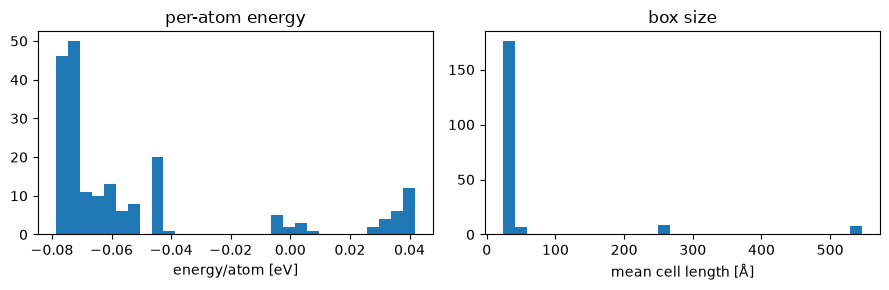

E/atom -0.079..0.042 eV ; cell 23.2..546.4 Å


In [3]:
epa = np.array([s["energy"]/len(s["atomic_numbers"]) for s in train_structs])
cellL = np.array([np.diag(s["cell"]).mean() for s in train_structs])
fig, ax = plt.subplots(1, 2, figsize=(9, 3.0))
ax[0].hist(epa, bins=30); ax[0].set_xlabel("energy/atom [eV]"); ax[0].set_title("per-atom energy")
ax[1].hist(cellL, bins=30); ax[1].set_xlabel("mean cell length [Å]"); ax[1].set_title("box size")
plt.tight_layout(); plt.show()
print(f"E/atom {epa.min():.3f}..{epa.max():.3f} eV ; cell {cellL.min():.1f}..{cellL.max():.1f} Å")

## 2. Build graphs: `xnn` **and** original NequIP data pipelines

We construct the dataset with each code's own neighbour-list machinery and compare
the resulting graphs and the average number of neighbours $\lambda$, which NequIP
uses to normalise messages by $1/\sqrt{\lambda}$ (`avg_num_neighbors`).

One data quirk first: the Argon set contains a few **fully vaporised** snapshots
(546 Å boxes) in which *no* pair of atoms is within the 6 Å cutoff. `xnn` (like
MACE) tolerates edgeless graphs (a local model simply predicts $\sum_i E_{0,z_i}$
for them), but the original `nequip` data pipeline **raises** on such frames.
Since they carry no learnable signal for a local potential either way, we drop
them from *both* pipelines so the two models see exactly the same data
(7 of 200 train frames, 2 of 50 test frames).


In [4]:
from xnn.common.data import AtomicDataset
from nequip.data import AtomicData, AtomicDataDict
from nequip.data.dataloader import DataLoader as NequipDataLoader
from nequip.data.transforms import TypeMapper

# --- drop the edgeless (fully vaporised) frames from both pipelines ---
def with_edges(structs):
    ds = AtomicDataset(structs, CUTOFF)
    keep = [i for i in range(len(structs)) if ds[i].num_edges > 0]
    return [structs[i] for i in keep], len(structs) - len(keep)

train_structs, n_drop_tr = with_edges(train_structs)
test_structs,  n_drop_te = with_edges(test_structs)
print(f"dropped edgeless frames: train {n_drop_tr}, test {n_drop_te} "
      "(nequip's pipeline rejects them; zero signal for a local model)")

# --- xnn graphs ---
xnn_train = AtomicDataset(train_structs, CUTOFF)
xnn_test  = AtomicDataset(test_structs,  CUTOFF)
xnn_edges = np.array([xnn_train[i].num_edges for i in range(len(xnn_train))])
xnn_atoms = np.array([xnn_train[i].num_nodes for i in range(len(xnn_train))])
LAMBDA = float(xnn_edges.sum() / xnn_atoms.sum())

# --- original NequIP graphs ---
TM = TypeMapper(chemical_symbols=["Ar"])
def to_nequip(structs):
    out = []
    for s in structs:
        d = AtomicData.from_points(
            pos=torch.tensor(s["pos"], dtype=torch.get_default_dtype()),
            r_max=CUTOFF,
            atomic_numbers=torch.tensor(s["atomic_numbers"]),
            cell=torch.tensor(s["cell"], dtype=torch.get_default_dtype()),
            pbc=torch.tensor([True, True, True]),
            total_energy=torch.tensor([s["energy"]], dtype=torch.get_default_dtype()),
            forces=torch.tensor(s["forces"], dtype=torch.get_default_dtype()))
        out.append(TM(d))
    return out
nequip_train = to_nequip(train_structs)
nequip_test  = to_nequip(test_structs)
nequip_edges = np.array([d.edge_index.shape[1] for d in nequip_train])

print(f"total edges     xnn = {int(xnn_edges.sum()):>8d}   nequip = {int(nequip_edges.sum()):>8d}")
print(f"per-frame edges max|xnn - nequip| = {np.abs(xnn_edges - nequip_edges).max()}"
      "  (identical neighbour lists)")
print(f"avg neighbours (edges/atom):  lambda = {LAMBDA:.3f}")
print(f"--> using avg_num_neighbors = {LAMBDA:.3f} for both models "
      "(upstream 'auto' computes the same statistic)")

dropped edgeless frames: train 7, test 2 (nequip's pipeline rejects them; zero signal for a local model)


total edges     xnn =  1372560   nequip =  1372558
per-frame edges max|xnn - nequip| = 2  (identical neighbour lists)
avg neighbours (edges/atom):  lambda = 17.779
--> using avg_num_neighbors = 17.779 for both models (upstream 'auto' computes the same statistic)


### One shared train / validation split

Both pipelines train on exactly the same configurations.


In [5]:
g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(train_structs), generator=g).tolist()
n_val = max(1, int(0.1 * len(train_structs)))
val_idx, train_idx = perm[:n_val], perm[n_val:]
print(f"train {len(train_idx)} configs / val {len(val_idx)} configs (identical for both models)")

train 174 configs / val 19 configs (identical for both models)


## 3. Build both models with identical hyper-parameters

A small-but-real NequIP: 3 layers, $\ell_{\max}=2$, parity on, 32 features,
radial MLP $2\times 64$, $\lambda$-normalised messages, trainable Bessel basis.
`xnn` is configured through the core `Config`; the original through its own
`model_from_config` builders (`SimpleIrrepsConfig`, `EnergyModel`,
`PerSpeciesRescale`, `ForceOutput`).


In [6]:
from xnn.common.config import from_dict
from xnn.common.models import build_model, ForceStressOutput
from nequip.model import model_from_config

HP = dict(r_max=CUTOFF, num_layers=3, l_max=2, parity=True, num_features=32,
          num_basis=8, PolynomialCutoff_p=6, invariant_layers=2, invariant_neurons=64,
          avg_num_neighbors=LAMBDA, use_sc=True, resnet=False)
EW, FW, LR, WD, BS, EPOCHS = 1.0, 100.0, 0.01, 5e-7, 10, 80

# ---- xnn model (core Config; unknown model keys fold into `extra`. Keys copied
# ---- verbatim from an upstream NequIP yaml (r_max, num_layers, num_basis,
# ---- chemical_symbols, per_species_rescale_shifts, ...) also work: the
# ---- translation registry in xnn.common.config.translate rewrites them to the
# ---- xnn canonical names at config-load time) ----
core = from_dict({
    "model": {"name": "nequip", "cutoff": HP["r_max"], "n_features": HP["num_features"],
              "n_interactions": HP["num_layers"], "n_rbf": HP["num_basis"],
              "species": SPECIES, "l_max": HP["l_max"], "parity": HP["parity"],
              "invariant_layers": HP["invariant_layers"],
              "invariant_neurons": HP["invariant_neurons"],
              "num_polynomial_cutoff": HP["PolynomialCutoff_p"],
              "avg_num_neighbors": LAMBDA, "atomic_energies": [E0[z] for z in SPECIES]},
    "data": {"batch_size": BS},
    "optim": {"lr": LR, "weight_decay": WD, "epochs": EPOCHS, "energy_weight": EW,
              "force_weight": FW, "scheduler": "plateau"},
    "device": DEVICE, "seed": 0, "output_dir": "runs/argon_xnn",
})
torch.manual_seed(0)
xnn_model = ForceStressOutput(build_model(core.model)).to(DEVICE)

# ---- original NequIP model ----
torch.manual_seed(0)
nequip_model = model_from_config(dict(
    model_builders=["SimpleIrrepsConfig", "EnergyModel", "PerSpeciesRescale", "ForceOutput"],
    chemical_symbols=["Ar"],
    per_species_rescale_shifts=[E0[z] for z in SPECIES],
    per_species_rescale_scales=[1.0],
    **HP), initialize=True).to(DEVICE)

p_xnn = sum(p.numel() for p in xnn_model.parameters())
p_nequip = sum(p.numel() for p in nequip_model.parameters())
print(f"parameters   xnn = {p_xnn:,}   nequip = {p_nequip:,}")
print(f"difference   = {p_xnn - p_nequip}  ==  xnn's `atom_ref` reference-energy table")
print("             (nn.Embedding(200, 1): 200 entries; nequip stores the per-species")
print("              shift as a fixed buffer instead. The learnable embedding/conv/")
print("              readout parameters are identical in count.)")

parameters   xnn = 208,128   nequip = 207,928
difference   = 200  ==  xnn's `atom_ref` reference-energy table
             (nn.Embedding(200, 1): 200 entries; nequip stores the per-species
              shift as a fixed buffer instead. The learnable embedding/conv/
              readout parameters are identical in count.)


## 3b. Are they the *same function*?  Weight transplant on the Argon data

Before training, we copy **every** weight from the original NequIP into the `xnn`
model and run both on real **periodic** Argon test configurations. Total energies
and per-atom forces match to `float32` round-off; the two implementations are the
same mapping, now including the periodic (cross-boundary) neighbours. (In `float64`
this agreement is ~$10^{-15}$; the block-by-block, non-periodic $10^{-16}$ proof is
in notebook 01.)


In [7]:
def transplant_full(xbase, nq_model, n_layers):
    '''Copy every learnable weight original nequip -> xnn (same member names).'''
    seq = nq_model.model.func                      # GraphModel -> EnergyModel sequential
    with torch.no_grad():
        xbase.edge_feat.rbf.freqs.copy_(seq.radial_basis.basis.bessel_weights)
        xbase.chemical_embedding.load_state_dict(seq.chemical_embedding.linear.state_dict())
        for i in range(n_layers):
            xbase.layers[i].conv.load_state_dict(
                getattr(seq, f"layer{i}_convnet").conv.state_dict())
        xbase.conv_to_output_hidden.load_state_dict(
            seq.conv_to_output_hidden.linear.state_dict())
        xbase.output_hidden_to_scalar.load_state_dict(
            seq.output_hidden_to_scalar.linear.state_dict())
        psr = seq.per_species_rescale
        for k, z in enumerate(SPECIES):
            xbase.atom_ref.weight[z] = psr.shifts[k]
            xbase.atom_scale[z] = psr.scales[k]

transplant_full(xnn_model.model, nequip_model, HP["num_layers"])

dE, dF = [], []
for k in range(8):                                  # first 8 test configs
    ox = xnn_model(xnn_test[k].to(DEVICE))
    dd = AtomicData.to_AtomicDataDict(
        next(iter(NequipDataLoader([nequip_test[k]], batch_size=1))).to(DEVICE))
    om = nequip_model(dd)
    dE.append(abs(float(ox["energy"]) - float(om["total_energy"].sum())))
    dF.append(np.abs(ox["forces"].detach().cpu().numpy()
                     - om["forces"].detach().cpu().numpy()).max())
print("transplanted models on Argon test configs (float32):")
print(f"  max |E_xnn - E_nequip|  = {max(dE):.2e} eV   (total energy of 400 atoms)")
print(f"  max |F_xnn - F_nequip|  = {max(dF):.2e} eV/Å  -> identical up to float32 round-off")

# re-init both freshly for a fair training comparison (independent of the transplant)
torch.manual_seed(0); xnn_model = ForceStressOutput(build_model(core.model)).to(DEVICE)
torch.manual_seed(0)
nequip_model = model_from_config(dict(
    model_builders=["SimpleIrrepsConfig", "EnergyModel", "PerSpeciesRescale", "ForceOutput"],
    chemical_symbols=["Ar"],
    per_species_rescale_shifts=[E0[z] for z in SPECIES],
    per_species_rescale_scales=[1.0],
    **HP), initialize=True).to(DEVICE)
print("\nboth models re-initialised for the training comparison below.")

transplanted models on Argon test configs (float32):
  max |E_xnn - E_nequip|  = 9.54e-06 eV   (total energy of 400 atoms)
  max |F_xnn - F_nequip|  = 1.45e-07 eV/Å  -> identical up to float32 round-off



both models re-initialised for the training comparison below.


## 4a. Train the `xnn` model (`xnn.train.Trainer`)

We pass the shared train/val split explicitly and record the per-epoch loss.


In [8]:
from torch.utils.data import Subset
from xnn.common.train import Trainer

xnn_tr = Subset(xnn_train, train_idx)
xnn_va = Subset(xnn_train, val_idx)
trainer = Trainer(core, xnn_tr, xnn_va)
trainer.model = xnn_model.to(trainer.device)      # use the freshly seeded model
trainer.opt = torch.optim.Adam(trainer.model.parameters(), lr=LR, weight_decay=WD)
trainer.sched = torch.optim.lr_scheduler.ReduceLROnPlateau(trainer.opt, patience=10)

hist_xnn = {"train": [], "val": []}
def _rec(epoch, tr, va):
    hist_xnn["train"].append(tr.get("loss")); hist_xnn["val"].append(va.get("loss"))
trainer._log = _rec                                # capture loss history

t0 = time.time(); trainer.fit(); t_xnn = time.time() - t0
print(f"xnn: trained {EPOCHS} epochs in {t_xnn:.1f} s | "
      f"final train {hist_xnn['train'][-1]:.4e} val {hist_xnn['val'][-1]:.4e}")

xnn: trained 80 epochs in 758.8 s | final train 4.2691e-04 val 3.4484e-04


## 4b. Train the **original NequIP** model: same data, loss, optimiser, schedule

A minimal native training loop over `nequip`'s own data pipeline. The loss is the
*identical* objective used by `xnn` (per-atom energy MSE + force MSE), with the
same Adam learning rate, weight decay, batch size, `ReduceLROnPlateau` schedule
and number of epochs, on the same configurations. The only difference is the model
implementation.


In [9]:
nq_tr_loader = NequipDataLoader([nequip_train[i] for i in train_idx],
                                batch_size=BS, shuffle=True)
nq_va_loader = NequipDataLoader([nequip_train[i] for i in val_idx],
                                batch_size=BS, shuffle=False)

opt = torch.optim.Adam(nequip_model.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10)

def nequip_loss(out, batch):
    n = (batch.ptr[1:] - batch.ptr[:-1]).to(out["total_energy"].dtype)  # atoms per config
    e = (((out["total_energy"].squeeze(-1) - batch.total_energy.squeeze(-1)) / n) ** 2).mean()
    f = ((out["forces"] - batch.forces) ** 2).mean()
    return EW * e + FW * f

hist_nequip = {"train": [], "val": []}
t0 = time.time()
for epoch in range(EPOCHS):
    nequip_model.train()
    tl = 0.0
    for b in nq_tr_loader:
        b = b.to(DEVICE)
        out = nequip_model(AtomicData.to_AtomicDataDict(b))
        loss = nequip_loss(out, b)
        opt.zero_grad(); loss.backward(); opt.step()
        tl += float(loss.detach())
    tl /= len(nq_tr_loader)

    nequip_model.eval(); vl = 0.0
    for b in nq_va_loader:
        b = b.to(DEVICE)
        out = nequip_model(AtomicData.to_AtomicDataDict(b))
        vl += float(nequip_loss(out, b).detach())
    vl /= len(nq_va_loader)
    sched.step(vl)
    hist_nequip["train"].append(tl); hist_nequip["val"].append(vl)
t_nequip = time.time() - t0
print(f"nequip: trained {EPOCHS} epochs in {t_nequip:.1f} s | "
      f"final train {hist_nequip['train'][-1]:.4e} val {hist_nequip['val'][-1]:.4e}")

nequip: trained 80 epochs in 732.9 s | final train 4.1325e-04 val 3.5331e-04


### Training-loss curves: both models


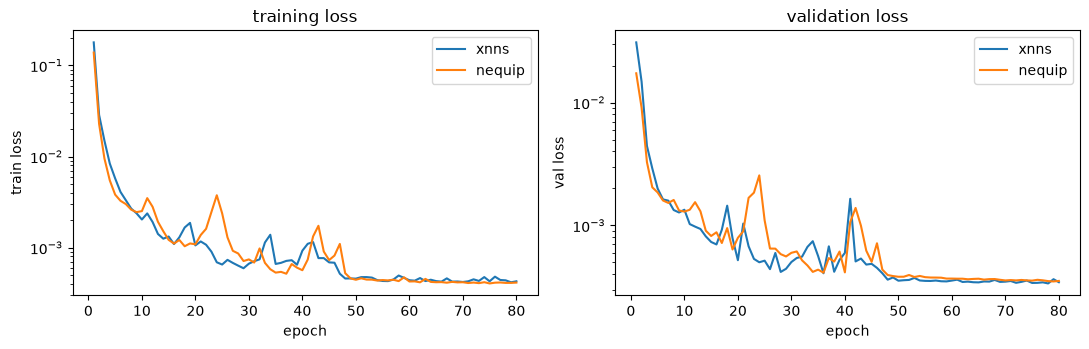

training time:  xnn 759s   nequip 733s


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ep = range(1, EPOCHS + 1)
ax[0].plot(ep, hist_xnn["train"], label="xnn"); ax[0].plot(ep, hist_nequip["train"], label="nequip")
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss"); ax[0].legend(); ax[0].set_title("training loss")
ax[1].plot(ep, hist_xnn["val"], label="xnn"); ax[1].plot(ep, hist_nequip["val"], label="nequip")
ax[1].set_yscale("log"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val loss"); ax[1].legend(); ax[1].set_title("validation loss")
plt.tight_layout(); plt.savefig("argon_loss_curves.png", dpi=120); plt.show()
print(f"training time:  xnn {t_xnn:.0f}s   nequip {t_nequip:.0f}s")

## 5. Evaluate both trained models on the held-out test set

Identical evaluation for each: predict energy + forces (autograd) on all 50 test
configurations and compute per-atom energy and force errors.


In [11]:
def eval_xnn(model):
    model.eval(); Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, i in zip(test_structs, range(len(xnn_test))):
        out = model(xnn_test[i].to(DEVICE))
        Ep.append(float(out["energy"].detach())); Er.append(s["energy"]); na.append(len(s["atomic_numbers"]))
        Fp.append(out["forces"].detach().cpu().numpy()); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def eval_nequip(model):
    model.eval(); Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, d in zip(test_structs, nequip_test):
        b = next(iter(NequipDataLoader([d], batch_size=1))).to(DEVICE)
        out = model(AtomicData.to_AtomicDataDict(b))
        Ep.append(float(out["total_energy"].sum().detach())); Er.append(s["energy"]); na.append(len(s["atomic_numbers"]))
        Fp.append(out["forces"].detach().cpu().numpy()); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def metrics(EpErNa, Fp, Fr):
    Ep, Er, na = EpErNa
    e = (Ep - Er) / na * 1000.0; f = (Fp - Fr) * 1000.0
    return dict(e_rmse=np.sqrt((e**2).mean()), e_mae=np.abs(e).mean(),
                f_rmse=np.sqrt((f**2).mean()), f_mae=np.abs(f).mean(),
                Ep=Ep/na, Er=Er/na, Fp=Fp, Fr=Fr)

res_x = metrics(*eval_xnn(trainer.model))
res_n = metrics(*eval_nequip(nequip_model))

print(f"{'metric':<22}{'xnn':>12}{'original NequIP':>18}")
print("-" * 52)
print(f"{'energy RMSE [meV/atom]':<22}{res_x['e_rmse']:>12.2f}{res_n['e_rmse']:>18.2f}")
print(f"{'energy MAE  [meV/atom]':<22}{res_x['e_mae']:>12.2f}{res_n['e_mae']:>18.2f}")
print(f"{'force  RMSE [meV/Å]':<22}{res_x['f_rmse']:>12.2f}{res_n['f_rmse']:>18.2f}")
print(f"{'force  MAE  [meV/Å]':<22}{res_x['f_mae']:>12.2f}{res_n['f_mae']:>18.2f}")

metric                        xnn   original NequIP
----------------------------------------------------
energy RMSE [meV/atom]       15.33             15.04
energy MAE  [meV/atom]       10.59             12.13
force  RMSE [meV/Å]           2.07              1.99
force  MAE  [meV/Å]           1.31              1.24


### Side-by-side parity plots


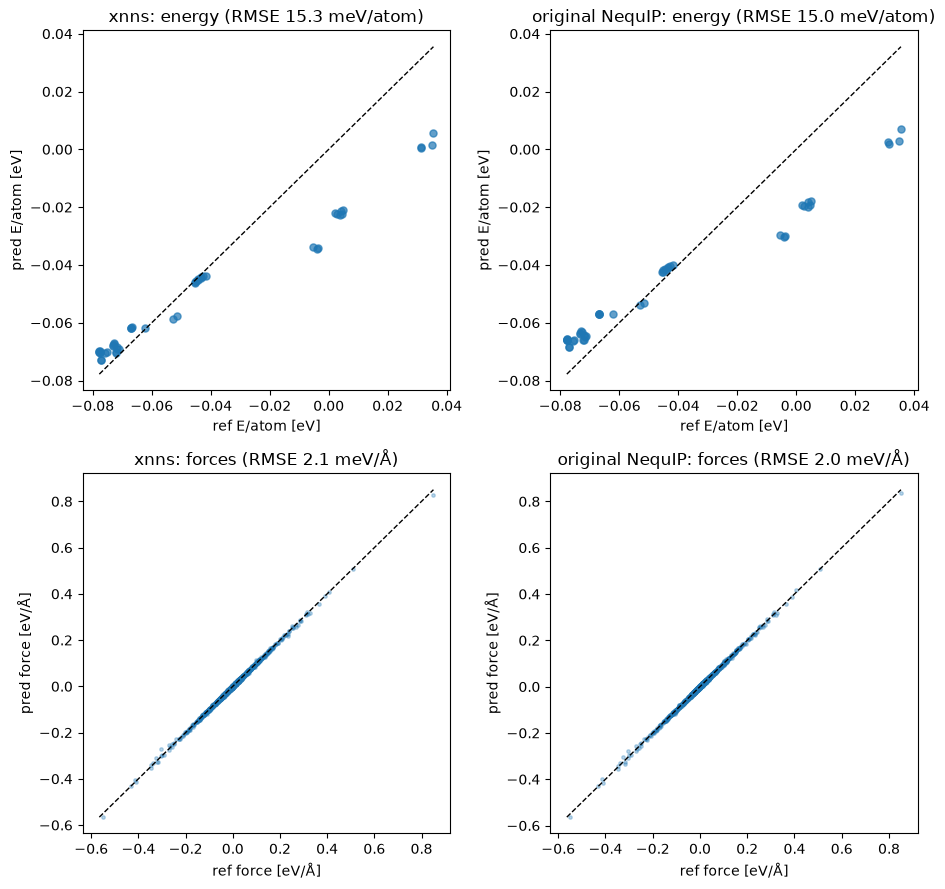

saved argon_parity_xnn_vs_nequip.png


In [12]:
fig, ax = plt.subplots(2, 2, figsize=(9.5, 9))
rng = np.random.default_rng(0)
idx = rng.choice(res_x["Fr"].size, size=4000, replace=False)
for col, (res, name) in enumerate([(res_x, "xnn"), (res_n, "original NequIP")]):
    a0 = ax[0, col]
    lim = [min(res["Er"].min(), res["Ep"].min()), max(res["Er"].max(), res["Ep"].max())]
    a0.plot(lim, lim, "k--", lw=1); a0.scatter(res["Er"], res["Ep"], s=26, alpha=0.7)
    a0.set_xlabel("ref E/atom [eV]"); a0.set_ylabel("pred E/atom [eV]")
    a0.set_title(f"{name}: energy (RMSE {res['e_rmse']:.1f} meV/atom)")
    a1 = ax[1, col]
    fr, fp = res["Fr"].ravel()[idx], res["Fp"].ravel()[idx]
    lim = [min(fr.min(), fp.min()), max(fr.max(), fp.max())]
    a1.plot(lim, lim, "k--", lw=1); a1.scatter(fr, fp, s=6, alpha=0.3)
    a1.set_xlabel("ref force [eV/Å]"); a1.set_ylabel("pred force [eV/Å]")
    a1.set_title(f"{name}: forces (RMSE {res['f_rmse']:.1f} meV/Å)")
plt.tight_layout(); plt.savefig("argon_parity_xnn_vs_nequip.png", dpi=120); plt.show()
print("saved argon_parity_xnn_vs_nequip.png")

## 6. `xnn` ASE calculator (deployment)

`xnn` ships an ASE `Calculator` for the trained model, the same one used for the
xnn MACE, because every xnn model shares the `AtomicGraph -> energy` contract.


In [13]:
from ase import Atoms
from xnn.common.deploy import XNNCalculator

s = test_structs[0]
atoms = Atoms(numbers=s["atomic_numbers"], positions=s["pos"], cell=s["cell"], pbc=True)
atoms.calc = XNNCalculator(trainer.model.to("cpu"), cutoff=CUTOFF)
print(f"ASE single point: E = {atoms.get_potential_energy():.4f} eV "
      f"({atoms.get_potential_energy()/len(atoms)*1000:.1f} meV/atom) | "
      f"max|F| = {np.abs(atoms.get_forces()).max():.4f} eV/Å")
print(f"reference       : E = {s['energy']:.4f} eV")

ASE single point: E = -27.9015 eV (-69.8 meV/atom) | max|F| = 0.0871 eV/Å
reference       : E = -31.0395 eV


## Summary: every stage compared

| stage | result |
|---|---|
| **Data → graphs** | xnn and `nequip` neighbour lists give the **identical edge set** (same counts) |
| **Model build** | identical architecture; parameter counts match except xnn's 200-entry `atom_ref` table ($E_0$ shift) |
| **Same function?** | transplanting weights gives **identical E and F on periodic Argon** (float32 round-off; ~1e-15 in float64) |
| **Training** | same data / loss / optimiser / schedule → **comparable loss curves** and final losses |
| **Test accuracy** | energy and force RMSE/MAE **agree** between the two implementations |

The `xnn` NequIP is a faithful, dependency-light (only `e3nn`) re-implementation
of the original NequIP: it not only matches block-by-block (notebook 01) but
delivers an **equivalent end-to-end training/testing pipeline** on realistic Argon
data. The small residual differences in trained metrics come only from independent
random initialisation and data shuffling; apply the transplant of Section 3b
before training to start both from identical weights if exact-match training
curves are desired.

`REF_stress` is also present in the data; periodic stress training can be enabled
with `compute_stress=True` / non-zero `stress_weight` (autograd strain trick on the
xnn side, `StressForceOutput` upstream). The companion notebook
`nequip_argon_density_md.ipynb` uses exactly that to run NPT molecular dynamics
with both codes.
